In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import sys
sys.path.append('..')  # so we can import from src/

from src.data_loader import load_twins_data

df = load_twins_data()

In [3]:
print(df.shape)

(23968, 53)


In [4]:
df.head()

,pldel,birattnd,brstate,stoccfipb,mager8,ormoth,mrace,meduc6,dmar,mplbir,...,infant_id,dlivord_min,dtotord_min,bord,brstate_reg,stoccfipb_reg,mplbir_reg,wt,treatment,outcome
0,1.0,1.0,1.0,1.0,3.0,0.0,1.0,3.0,1.0,1.0,...,35.0,3.0,3.0,2.0,5.0,5.0,5.0,936.0,0,0.0
1,1.0,1.0,1.0,1.0,3.0,0.0,1.0,3.0,1.0,1.0,...,34.0,3.0,3.0,1.0,5.0,5.0,5.0,1006.0,1,0.0
2,1.0,1.0,1.0,1.0,3.0,0.0,1.0,2.0,0.0,1.0,...,47.0,NaN,NaN,NaN,5.0,5.0,5.0,737.0,0,0.0
3,1.0,1.0,1.0,1.0,3.0,0.0,1.0,2.0,0.0,1.0,...,46.0,NaN,NaN,NaN,5.0,5.0,5.0,850.0,1,1.0
4,1.0,1.0,1.0,1.0,3.0,0.0,1.0,3.0,1.0,1.0,...,52.0,1.0,1.0,1.0,5.0,5.0,5.0,1830.0,0,0.0


In [5]:
print(df.columns.tolist())

['pldel', 'birattnd', 'brstate', 'stoccfipb', 'mager8', 'ormoth', 'mrace', 'meduc6', 'dmar', 'mplbir', 'mpre5', 'adequacy', 'orfath', 'frace', 'birmon', 'gestat10', 'csex', 'anemia', 'cardiac', 'lung', 'diabetes', 'herpes', 'hydra', 'hemo', 'chyper', 'phyper', 'eclamp', 'incervix', 'pre4000', 'preterm', 'renal', 'rh', 'uterine', 'othermr', 'tobacco', 'alcohol', 'cigar6', 'drink5', 'crace', 'data_year', 'nprevistq', 'dfageq', 'feduc6', 'infant_id', 'dlivord_min', 'dtotord_min', 'bord', 'brstate_reg', 'stoccfipb_reg', 'mplbir_reg', 'wt', 'treatment', 'outcome']


In [6]:
print(df["treatment"].value_counts())
print("---")
print(df["outcome"].value_counts())
print("---")
print(df["wt"].max())

treatment
0    11984
1    11984
Name: count, dtype: int64
---
outcome
0.0    19730
1.0     4238
Name: count, dtype: int64
---
1999.0


In [7]:
print("Tobacco:")
print(df['tobacco'].value_counts(dropna=False))

print("\nAlcohol:")
print(df['alcohol'].value_counts(dropna=False))

print("\nEither exposure:")
either = (df["tobacco"] == 1) | (df["alcohol"] == 1)
print(either.value_counts())

Tobacco:
tobacco
0.0    13828
NaN     6176
1.0     3964
Name: count, dtype: int64

Alcohol:
alcohol
0.0    17500
NaN     5828
1.0      640
Name: count, dtype: int64

Either exposure:
False    19848
True      4120
Name: count, dtype: int64


In [8]:
# Remove rows with missing tobacco or alcohol
df_no_missing = df.dropna(subset=['tobacco','alcohol'])

print(f"Original shape: {df.shape}")
print(f"After dropping missing exposure: {df_no_missing.shape}")
print(f"Row count is even: {df_no_missing.shape[0] % 2 == 0}")
print(f"Rows dropped: {df.shape[0] - df_no_missing.shape[0]}")

Original shape: (23968, 53)
After dropping missing exposure: (17688, 53)
Row count is even: True
Rows dropped: 6280


In [9]:
print(f"Pairs remaining: {df_no_missing.shape[0] // 2}")
print(f"\nExposure breakdown:")
either = (df_no_missing['tobacco'] == 1) | (df_no_missing['alcohol'] == 1)
print(either.value_counts())
print(f"\nMortality rate: {df_no_missing['outcome'].mean():.3%}")

Pairs remaining: 8844

Exposure breakdown:
False    13638
True      4050
Name: count, dtype: int64

Mortality rate: 17.622%


Creating a table to hold variables and definitions

In [10]:
variables = pd.DataFrame([
    {"variable": "treatment", "role": "Treatment", "type": "Binary", 
     "description": "1 if heavier twin in the pair, 0 if lighter"},
    {"variable": "outcome", "role": "Outcome", "type": "Binary", 
     "description": "1 if death in first year, 0 otherwise"},
    {"variable": "gestat10", "role": "Confounder", "type": "Ordinal",
     "description": "The number of gestational weeks prior to birth binned into 10 ordered categories (higher = longer gestation)"},
    {"variable": "tobacco, alcohol", "role": "Exposure (subgroup)", "type": "Binary",
     "description": "Maternal prenatal substance use during pregnancy. Combined into a single 'any exposure' indicator for subgroup analysis."},
    {"variable": "Maternal demographics (mager8, mrace, meduc6, dmar, mplbir, ormoth)", "role": "Covariate", "type": "Mixed",
     "description": "Mother's age, race, education, marital status, place of birth, and origin"},
    {"variable": "Paternal demographics (orfath, frace, feduc6, dfageq)", "role": "Covariate", "type": "Mixed",
     "description": "Father's age, race, education, and origin"},
    {"variable": "Maternal health conditions (anemia, cardiac, lung, diabetes, herpes, hydra, hemo, chyper, phyper, eclamp, incervix, pre4000, preterm, renal, rh, uterine, othermr)", "role": "Covariate", "type": "Binary",
     "description": "Health condition indicators and complications during pregnancy"},
    {"variable": "Prenatal care (mpre5, adequacy, nprevistq)", "role": "Covariate", "type": "Mixed",
     "description": "Month prenatal care began, adequacy of care, and number of prenatal visits"},
    {"variable": "Birth circumstances (pldel, birattnd, birmon, csex, crace)", "role": "Covariate", "type": "Mixed",
     "description": "Place of delivery, birth attendant, month of birth, infant sex, and race"},
    {"variable": "Geographic (brstate, stoccfipb, brstate_reg, stoccfipb_reg, mplbir_reg)", "role": "Covariate", "type": "Categorical",
     "description": "State and regional identifiers"},
    {"variable": "Substance use intensity (cigar6, drink5)", "role": "Covariate", "type": "Ordinal",
     "description": "Cigarettes per day and drinks per week"},
    {"variable": "Infant variables (infant_id, bord, dlivord_min, dtotord_min)", "role": "Covariate", "type": "Mixed",
     "description": "Infant identifier, birth order, and birth order minimums"},
    {"variable": "Other (data_year)", "role": "Covariate", "type": "Integer",
     "description": "Year of birth record"}
])
variables

,variable,role,type,description
0,treatment,Treatment,Binary,"1 if heavier twin in the pair, 0 if lighter"
1,outcome,Outcome,Binary,"1 if death in first year, 0 otherwise"
2,gestat10,Confounder,Ordinal,The number of gestational weeks prior to birth...
3,"tobacco, alcohol",Exposure (subgroup),Binary,Maternal prenatal substance use during pregnan...
4,"Maternal demographics (mager8, mrace, meduc6, ...",Covariate,Mixed,"Mother's age, race, education, marital status,..."
5,"Paternal demographics (orfath, frace, feduc6, ...",Covariate,Mixed,"Father's age, race, education, and origin"
6,"Maternal health conditions (anemia, cardiac, l...",Covariate,Binary,Health condition indicators and complications ...
7,"Prenatal care (mpre5, adequacy, nprevistq)",Covariate,Mixed,"Month prenatal care began, adequacy of care, a..."
8,"Birth circumstances (pldel, birattnd, birmon, ...",Covariate,Mixed,"Place of delivery, birth attendant, month of b..."
9,"Geographic (brstate, stoccfipb, brstate_reg, s...",Covariate,Categorical,State and regional identifiers


In [11]:
variables.to_csv("../figures/variable_description.csv", index=False)

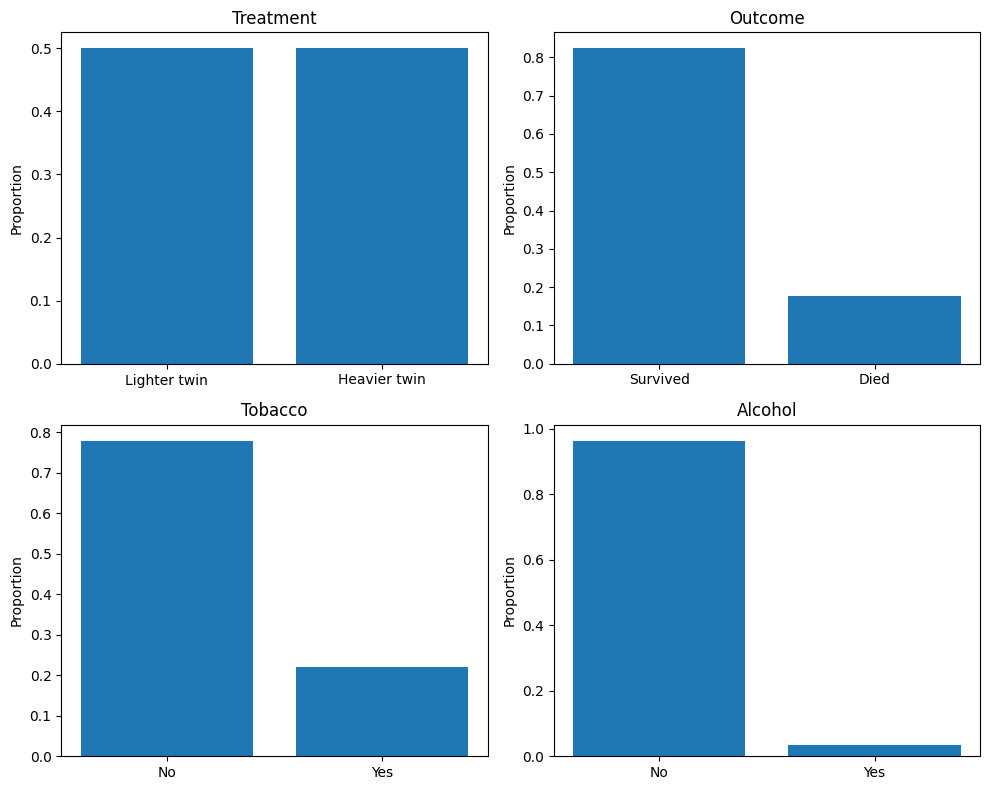

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Treatment
treatment_props = df_no_missing["treatment"].value_counts(normalize=True).sort_index()
axes[0, 0].bar(["Lighter twin", "Heavier twin"], treatment_props.values)
axes[0, 0].set_title("Treatment")
axes[0, 0].set_ylabel("Proportion")

# Outcome  
outcome_props = df_no_missing['outcome'].value_counts(normalize=True).sort_index()
axes[0,1].bar(["Survived", "Died"], outcome_props.values)
axes[0,1].set_title("Outcome")
axes[0,1].set_ylabel("Proportion")

# Tobacco
tob_props = df_no_missing["tobacco"].value_counts(normalize=True).sort_index()
axes[1,0].bar(["No", "Yes"], tob_props.values)
axes[1,0].set_title("Tobacco")
axes[1,0].set_ylabel("Proportion")

# Bottom-right: alcohol
alc_props = df_no_missing["alcohol"].value_counts(normalize=True).sort_index()
axes[1,1].bar(["No", "Yes"], alc_props.values)
axes[1,1].set_title("Alcohol")
axes[1,1].set_ylabel("Proportion")

plt.tight_layout()
plt.savefig("../figures/binary_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

Figure 1. Distribution of key binary variables in the analytic sample (N = 17,688 twins, 8,844 pairs). Treatment is balanced 50/50 by construction, since each pair contributes one heavier-twin (T=1) and one lighter-twin (T=0) observation. The first-year mortality rate is 17.6%, reflecting the high-risk population of twins born under 2kg. Tobacco exposure is recorded for 22.2% of mothers, while alcohol exposure is rare at 3.6%. The disparity in exposure prevalence motivates combining both into a single "any exposure" indicator for the subgroup analysis.

In [13]:
# Combining the alcohol and tobacco fields to get a combined "any_exposure"
df_no_missing["any_exposure"] = ((df_no_missing["tobacco"] == 1)|(df_no_missing["alcohol"] == 1)).astype(int)
print(df_no_missing["any_exposure"].value_counts())

any_exposure
0    13638
1     4050
Name: count, dtype: int64


In [14]:
# Obtaining mortality rate by treatment
df_no_missing.groupby("treatment")["outcome"].mean().sort_index()

treatment
0    0.189281
1    0.163161
Name: outcome, dtype: float64

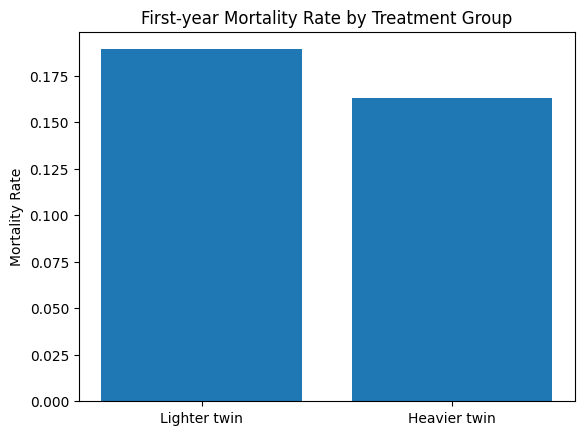

In [15]:
mort_rates = df_no_missing.groupby("treatment")["outcome"].mean().sort_index()
plt.bar(["Lighter twin", "Heavier twin"], mort_rates.values)
plt.title("First-year Mortality Rate by Treatment Group")
plt.ylabel("Mortality Rate")
plt.savefig("../figures/naive_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

Figure 2. First-year mortality rate by treatment group. Lighter twins die at 18.9%, while heavier twins die at 16.3%, a naive difference of 2.6 percentage points favoring the heavier twin. This unadjusted comparison overstates the causal effect of being the heavier twin because longer gestation simultaneously increases birth weight and reduces mortality risk. Adjusting for gestational age and other covariates through the doubly robust estimator and T-Learner (Sections 4 and 5) is required to recover the true causal effect.

The naive estimate is too large in magnitude because gestational age and treatment are positively correlated.

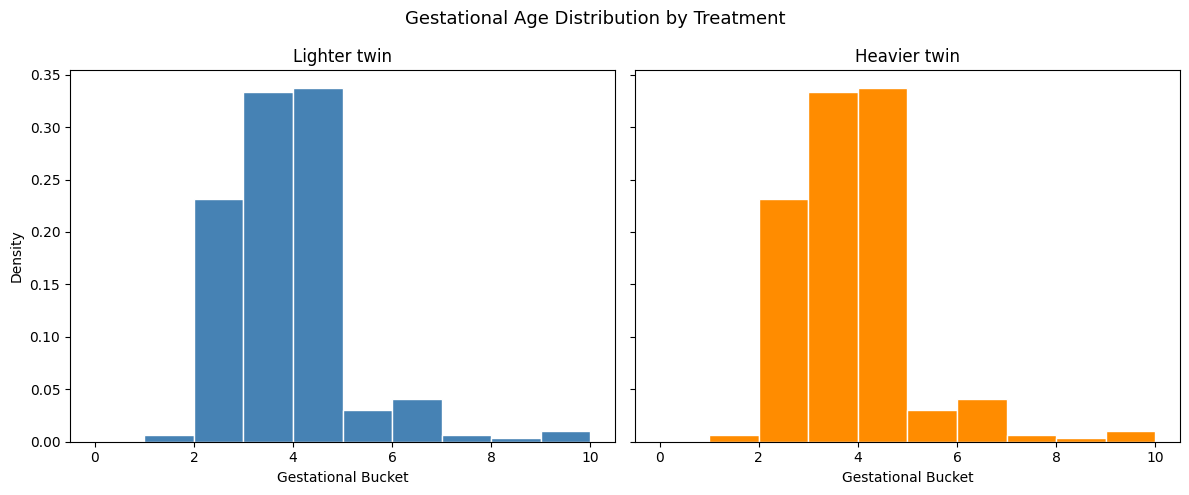

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

lighter = df_no_missing[df_no_missing["treatment"]==0]["gestat10"]
heavier = df_no_missing[df_no_missing["treatment"]==1]["gestat10"]

axes[0].hist(lighter, bins=range(11), density=True, color="steelblue", edgecolor="white")
axes[0].set_title("Lighter twin")
axes[0].set_xlabel("Gestational Bucket")
axes[0].set_ylabel("Density")

axes[1].hist(heavier, bins=range(11), density=True, color="darkorange", edgecolor="white")
axes[1].set_title("Heavier twin")
axes[1].set_xlabel("Gestational Bucket")

fig.suptitle("Gestational Age Distribution by Treatment", fontsize=13)

plt.tight_layout()
plt.savefig("../figures/gestat10_balance.png", dpi=150, bbox_inches="tight")
plt.show()

Distribution of gestational age (gestat10) by treatment group. 

The two distributions are nearly identical because both twins in a pair share their mother's gestation, so maternal variables are marginally balanced across treatment groups by construction. This within-pair structure means that confounding in this dataset operates primarily through infant-specific variables rather than maternal ones, motivating the use of full-covariate adjustment in the causal estimation that follows.

In [17]:
# Saving processed data
df_no_missing.to_csv("../data/processed/twins_clean.csv", index=False)

In [18]:
# Examining if there are any rows where twins have the same weight
weights = df_no_missing['wt'].values
n_pairs = len(weights) // 2
tied_pairs = sum(weights[2*i] == weights[2*i + 1] for i in range(n_pairs))
print(f"Pairs with tied weights: {tied_pairs}")
print(f"Total pairs: {n_pairs}")

Pairs with tied weights: 0
Total pairs: 8844


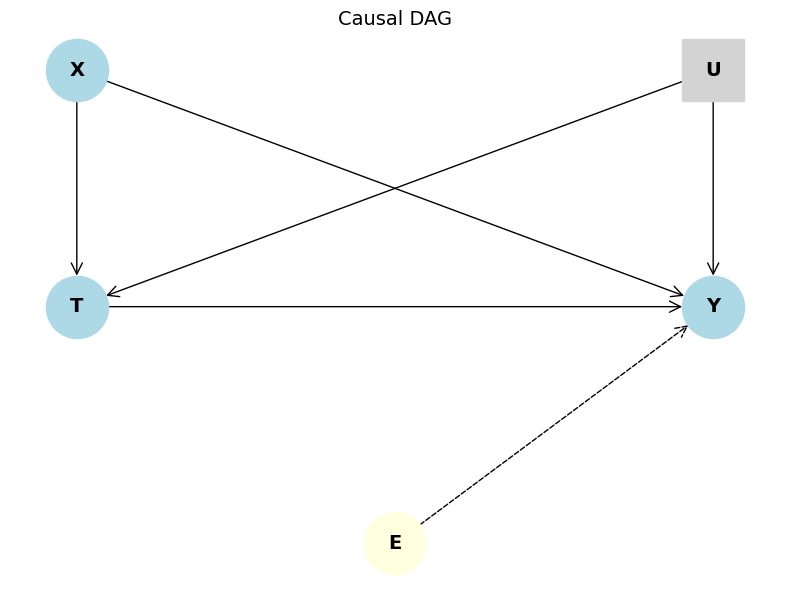

In [19]:
G = nx.DiGraph()

nodes = ['X', 'U', 'T', 'Y', 'E']
G.add_nodes_from(nodes)

positions = {
    'X': (0,2),
    'U': (2,2),
    'T': (0,1),
    'Y': (2,1),
    'E': (1,0)
}
solid_edges = [
    ('X', 'T'),
    ('X', 'Y'),
    ('U', 'T'),
    ('U', 'Y'),
    ('T', 'Y')
]
G.add_edges_from(solid_edges)

fig, ax = plt.subplots(figsize=(8,6))

# Create default nodes 
nx.draw_networkx_nodes(G, positions, nodelist = ["T", "Y", "X"], node_color = "lightblue", node_size = 2000, ax = ax)
# Create unobserved confounder
nx.draw_networkx_nodes(G, positions, nodelist=["U"], node_color="lightgray", node_size=2000, node_shape="s", ax=ax)
# Create effect modifier 
nx.draw_networkx_nodes(G, positions, nodelist = ["E"], node_color = "lightyellow", node_size = 2000, ax = ax)
# Create edges
nx.draw_networkx_edges(G, positions, edgelist=solid_edges, 
                       arrows=True, arrowsize=20, arrowstyle='->', 
                       node_size=2000, ax=ax)

# Create dashed edges for E -> Y
nx.draw_networkx_edges(G, positions, edgelist=[("E", "Y")], 
                       arrows=True, arrowsize=20, arrowstyle='->', 
                       style="dashed", node_size=2000, ax=ax)
# Create labels
nx.draw_networkx_labels(G, positions, font_size = 14, font_weight = "bold", ax = ax)

ax.set_title("Causal DAG", fontsize = 14)
ax.axis("off")
plt.tight_layout()
plt.savefig("../figures/causal_dag.png", dpi = 150, bbox_inches = "tight")

plt.show()

In [20]:
# Determine which columns will be removed
for col in df_no_missing.columns:
    n_unique = df_no_missing[col].nunique()
    n_missing = df_no_missing[col].isna().sum()
    print(f"{col:20s} unique={n_unique:6d}  missing={n_missing:6d}  dtype={df_no_missing[col].dtype}")

pldel                unique=     4  missing=     6  dtype=float64
birattnd             unique=     5  missing=    20  dtype=float64
brstate              unique=    54  missing=     0  dtype=float64
stoccfipb            unique=    47  missing=     0  dtype=float64
mager8               unique=     8  missing=     0  dtype=float64
ormoth               unique=     6  missing=   190  dtype=float64
mrace                unique=     9  missing=     0  dtype=float64
meduc6               unique=     5  missing=   412  dtype=float64
dmar                 unique=     2  missing=     0  dtype=float64
mplbir               unique=    56  missing=    62  dtype=float64
mpre5                unique=     4  missing=   672  dtype=float64
adequacy             unique=     3  missing=  1130  dtype=float64
orfath               unique=     6  missing=  4382  dtype=float64
frace                unique=     9  missing=  4270  dtype=float64
birmon               unique=    12  missing=     0  dtype=float64
gestat10  

In [ ]:
exclude = ['infant_id', 'wt', 'treatment', 'outcome', 'any_exposure',
           'orfath', 'frace', 'dfageq', 'feduc6',
           'brstate', 'stoccfipb', 'mplbir']
covariates = [c for c in df_no_missing.columns if c not in exclude]
print(f"Number of covariates: {len(covariates)}")
print(covariates)

Number of covariates: 42
['pldel', 'birattnd', 'mager8', 'ormoth', 'mrace', 'meduc6', 'dmar', 'mpre5', 'adequacy', 'birmon', 'gestat10', 'csex', 'anemia', 'cardiac', 'lung', 'diabetes', 'herpes', 'hydra', 'hemo', 'chyper', 'phyper', 'eclamp', 'incervix', 'pre4000', 'preterm', 'renal', 'rh', 'uterine', 'othermr', 'tobacco', 'alcohol', 'cigar6', 'drink5', 'crace', 'data_year', 'nprevistq', 'dlivord_min', 'dtotord_min', 'bord', 'brstate_reg', 'stoccfipb_reg', 'mplbir_reg']


In [22]:
ordinal_cols = ['mager8', 'meduc6', 'mpre5', 'adequacy', 'gestat10', 
                'cigar6', 'drink5', 'nprevistq', 
                'dlivord_min', 'dtotord_min']

nominal_cols = ['pldel', 'birattnd', 'ormoth', 'mrace', 'dmar', 
                'birmon', 'csex', 'anemia', 'cardiac', 'lung', 'diabetes', 
                'herpes', 'hydra', 'hemo', 'chyper', 'phyper', 'eclamp', 
                'incervix', 'pre4000', 'preterm', 'renal', 'rh', 'uterine', 
                'othermr', 'tobacco', 'alcohol', 'crace', 'data_year', 
                'bord', 'brstate_reg', 'stoccfipb_reg', 'mplbir_reg']

print(f"Ordinal: {len(ordinal_cols)}, Nominal: {len(nominal_cols)}, Total: {len(ordinal_cols) + len(nominal_cols)}")
assert len(ordinal_cols) + len(nominal_cols) == 42
assert set(ordinal_cols + nominal_cols) == set(covariates)
print("Groups are complete and non-overlapping")

Ordinal: 10, Nominal: 32, Total: 42
Groups are complete and non-overlapping


In [23]:
# Reset index so positions are clean consecutive integers
df_check = df_no_missing.reset_index(drop=True)
df_check['pair_id'] = df_check.index // 2

# Each pair should have exactly 2 rows
pair_sizes = df_check.groupby('pair_id').size()
print(f"All pairs have exactly 2 rows: {(pair_sizes == 2).all()}")
print(f"Number of pairs: {len(pair_sizes)}")

# Each pair should have exactly one treated (T=1) and one control (T=0)
treatment_sums = df_check.groupby('pair_id')['treatment'].sum()
print(f"All pairs have exactly one treated twin: {(treatment_sums == 1).all()}")

# Each pair should share the same maternal exposure (sanity check on within-pair structure)
exposure_consistency = df_check.groupby('pair_id')['any_exposure'].nunique()
print(f"All pairs share the same exposure status: {(exposure_consistency == 1).all()}")

All pairs have exactly 2 rows: True
Number of pairs: 8844
All pairs have exactly one treated twin: True
All pairs share the same exposure status: True
